# Topic Analysis of Patent-Cited and Policy-Cited Scholarly Literature

This notebook performs topic interpretation and comparative analysis of
patent-cited and policy-cited scholarly literature.

The computational preprocessing and LDA model-selection stages were completed
in the preceding topic-modeling notebook. Their outputs were saved to disk
and are loaded here rather than recomputed.

The analysis in this notebook focuses on:

1. reviewing model-selection diagnostics;
2. selecting the final topic resolution for each corpus;
3. fitting and extracting the final LDA models;
4. identifying representative publications;
5. interpreting and labeling latent topics;
6. estimating probability-weighted topic prevalence;
7. comparing thematic patterns between patent-cited and policy-cited
   scholarly literature; and
8. examining temporal patterns where supported by the data.

Topic labeling and higher-level thematic mapping are interpretive stages and
therefore require manual validation rather than being treated as fully
automated outputs.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import subprocess


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR


DATA_DIR = (
    PROJECT_DIR
    / "data"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "output"
)

ANALYSIS_OUTPUT_DIR = (
    OUTPUT_DIR
    / "patent_policy_topic_modeling"
)

METADATA_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "metadata"
)

R_PREPROCESS_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "r_preprocessing"
)

LDA_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "lda"
)

MODEL_SELECTION_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "model_selection"
)

TOPIC_INTERPRETATION_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "topic_interpretation"
)

TOPIC_PREVALENCE_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "topic_prevalence"
)

COMPARISON_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "cross_corpus_comparison"
)

TEMPORAL_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "temporal_analysis"
)

FIGURE_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "figures"
)


for directory in [
    TOPIC_INTERPRETATION_DIR,
    TOPIC_PREVALENCE_DIR,
    COMPARISON_DIR,
    TEMPORAL_DIR,
    FIGURE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project directory :", PROJECT_DIR)
print("Analysis output   :", ANALYSIS_OUTPUT_DIR)
print("Model selection   :", MODEL_SELECTION_DIR)
print("LDA directory     :", LDA_DIR)
print("Metadata          :", METADATA_DIR)
print("Figures           :", FIGURE_DIR)

Project directory : m:\projects_latex\review_paper_2
Analysis output   : m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling
Model selection   : m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling\model_selection
LDA directory     : m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling\lda
Metadata          : m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling\metadata
Figures           : m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling\figures


## 1. Load Saved Model-Selection Results

The model-selection outputs generated by the preceding notebook are loaded
from disk.

For each corpus, these include the coarse and extended topic-number searches,
candidate-model diagnostics, topic-level coherence measurements, and
candidate top terms.

Loading the saved outputs avoids repeating the computationally expensive LDA
model-selection procedure.

In [3]:
corpus_names = [
    "patent_cited",
    "policy_cited",
]

candidate_results = {}
candidate_topic_diagnostics = {}
candidate_top_terms = {}
combined_k_results = {}


for corpus_name in corpus_names:

    candidate_results[
        corpus_name
    ] = pd.read_csv(
        MODEL_SELECTION_DIR
        / f"{corpus_name}_candidate_evaluation.csv"
    )

    candidate_topic_diagnostics[
        corpus_name
    ] = pd.read_csv(
        MODEL_SELECTION_DIR
        / f"{corpus_name}_candidate_topic_diagnostics.csv"
    )

    candidate_top_terms[
        corpus_name
    ] = pd.read_csv(
        MODEL_SELECTION_DIR
        / f"{corpus_name}_candidate_top_terms.csv"
    )

    combined_k_results[
        corpus_name
    ] = pd.read_csv(
        MODEL_SELECTION_DIR
        / f"{corpus_name}_combined_k_search.csv"
    )


print(
    "Saved model-selection results loaded."
)

Saved model-selection results loaded.


### 1.1 Validate Loaded Model-Selection Outputs

The loaded files are checked before interpretation to confirm that all
candidate topic resolutions and their associated topic-level outputs are
available.

This validation ensures that the interpretation notebook is operating from
the completed model-selection results rather than partially generated files.

In [4]:
for corpus_name in corpus_names:

    print()
    print(
        corpus_name
        .replace("_", " ")
        .upper()
    )

    print(
        "=" * 50
    )

    print(
        "Candidate models :",
        len(
            candidate_results[
                corpus_name
            ]
        )
    )

    print(
        "Candidate K      :",
        candidate_results[
            corpus_name
        ]["K"].tolist()
    )

    print(
        "Topic diagnostics:",
        len(
            candidate_topic_diagnostics[
                corpus_name
            ]
        )
    )

    print(
        "Top-term rows    :",
        len(
            candidate_top_terms[
                corpus_name
            ]
        )
    )

    print(
        "Screened K       :",
        combined_k_results[
            corpus_name
        ]["K"].tolist()
    )


PATENT CITED
Candidate models : 4
Candidate K      : [20, 30, 40, 50]
Topic diagnostics: 140
Top-term rows    : 1400
Screened K       : [5, 10, 15, 20, 25, 30, 40, 50, 60]

POLICY CITED
Candidate models : 4
Candidate K      : [20, 30, 40, 50]
Topic diagnostics: 140
Top-term rows    : 1400
Screened K       : [5, 10, 15, 20, 25, 30, 40, 50, 60]


## 2. Final Topic-Number Selection

The final number of latent topics is selected independently for the
patent-cited and policy-cited corpora.

Topic-number selection considers several complementary sources of evidence:

- the shape of the held-out perplexity curve;
- the marginal improvement in perplexity as \(K\) increases;
- semantic coherence;
- inter-topic similarity; and
- substantive interpretability of the resulting topics.

The final value of \(K\) is therefore not selected solely because it produces
the lowest perplexity. Increasing \(K\) generally provides greater thematic
resolution and may improve predictive fit, but excessive topic resolution
can fragment coherent themes into small or difficult-to-interpret topics.

The objective is to identify a topic resolution that provides useful thematic
detail without unnecessary fragmentation.

In [5]:
model_selection_tables = {}


for corpus_name in corpus_names:

    results = (
        candidate_results[
            corpus_name
        ]
        .copy()
        .sort_values("K")
        .reset_index(drop=True)
    )

    results[
        "Previous_Perplexity"
    ] = (
        results[
            "Perplexity"
        ]
        .shift(1)
    )

    results[
        "Perplexity_Improvement"
    ] = (
        results[
            "Previous_Perplexity"
        ]
        -
        results[
            "Perplexity"
        ]
    )

    results[
        "Improvement_Percent"
    ] = (
        100
        * results[
            "Perplexity_Improvement"
        ]
        / results[
            "Previous_Perplexity"
        ]
    )

    model_selection_tables[
        corpus_name
    ] = results

    print()
    print(
        corpus_name
        .replace("_", " ")
        .upper()
    )

    print(
        "=" * 50
    )

    display(
        results[
            [
                "K",
                "Perplexity",
                "Perplexity_Improvement",
                "Improvement_Percent",
                "Mean_Coherence",
                "Median_Coherence",
                "Mean_Similarity",
                "Max_Similarity",
            ]
        ]
    )


PATENT CITED


,K,Perplexity,Perplexity_Improvement,Improvement_Percent,Mean_Coherence,Median_Coherence,Mean_Similarity,Max_Similarity
0,20,498.701427,NaN,NaN,-67.322782,-69.298065,0.041738,0.367928
1,30,482.421013,16.280414,3.264561,-70.575573,-70.732801,0.044840,0.597921
2,40,466.123642,16.297371,3.378246,-73.550158,-72.615672,0.041849,0.676577
3,50,456.823276,9.300366,1.995257,-75.398433,-75.827026,0.039749,0.693252



POLICY CITED


,K,Perplexity,Perplexity_Improvement,Improvement_Percent,Mean_Coherence,Median_Coherence,Mean_Similarity,Max_Similarity
0,20,556.652838,NaN,NaN,-63.591437,-64.474449,0.044296,0.269884
1,30,542.951173,13.701664,2.461438,-63.944172,-64.882839,0.041856,0.331223
2,40,525.576888,17.374286,3.199972,-68.502849,-66.651181,0.039787,0.745435
3,50,520.546930,5.029958,0.957036,-70.470997,-70.799635,0.039326,0.628700


### 2.2 Perplexity Curves Across Topic Numbers

Held-out perplexity is plotted against the number of latent topics to
visualize the change in predictive performance as topic resolution
increases.

Lower perplexity indicates better predictive performance on the held-out
documents. However, the final topic number is not selected solely from the
minimum perplexity. Instead, the curve is examined for diminishing
improvements as \(K\) increases, and the resulting candidate models are
subsequently evaluated using topic coherence, topic similarity, and manual
interpretability.

Separate curves are produced for the patent-cited and policy-cited scholarly
corpora because the two LDA models are estimated independently.

Saved: m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling\figures\patent_cited_perplexity_by_k.pdf


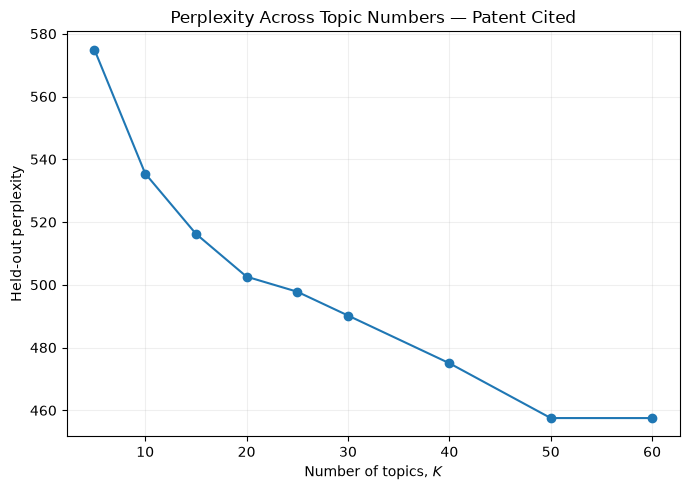

Saved: m:\projects_latex\review_paper_2\output\patent_policy_topic_modeling\figures\policy_cited_perplexity_by_k.pdf


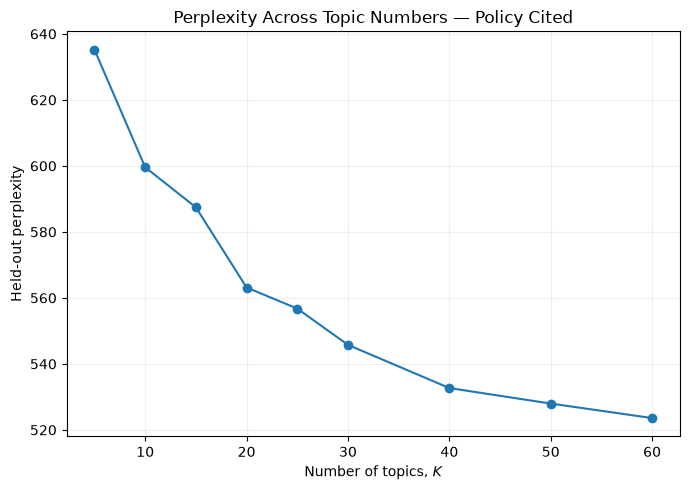

In [6]:
# ---------------------------------------------------------
# Plot perplexity versus K
# ---------------------------------------------------------

for corpus_name in corpus_names:

    results = (
        combined_k_results[
            corpus_name
        ]
        .copy()
        .sort_values("K")
        .reset_index(drop=True)
    )

    display_name = (
        corpus_name
        .replace("_", " ")
        .title()
    )

    # -----------------------------------------------------
    # Figure
    # -----------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.plot(
        results["K"],
        results["Perplexity"],
        marker="o",
        linewidth=1.5,
    )

    ax.set_xlabel(
        "Number of topics, $K$"
    )

    ax.set_ylabel(
        "Held-out perplexity"
    )

    ax.set_title(
        f"Perplexity Across Topic Numbers — {display_name}"
    )

    ax.grid(
        alpha=0.20
    )

    fig.tight_layout()

    # -----------------------------------------------------
    # Save PDF
    # -----------------------------------------------------

    output_file = (
        FIGURE_DIR
        / f"{corpus_name}_perplexity_by_k.pdf"
    )

    fig.savefig(
        output_file,
        format="pdf",
        bbox_inches="tight",
    )

    print(
        "Saved:",
        output_file
    )

    plt.show()